# 14 — Spherical mass mapping: field-level reconstruction of two $\kappa$ maps

Field-level mass mapping on a 1LPT lightcone. The data are two noisy spherical convergence maps with DES Y3-like shape noise ($\sigma_e = 0.26$, $n_\mathrm{gal} = 1.5\ \mathrm{arcmin}^{-2}$ per tomographic bin) for sources at $z_s = 0.45$ and $0.75$; the reconstruction varies the white `initial_conditions` field through the forward model until the predicted $\kappa$ matches, at a **fixed cosmology** (the truth draw). Because `lensing_output="convergence"`, the observable *is* the pair of $\kappa$ maps — what the likelihood fits and what the notebook publishes are the same object, with no Born projection bolted on afterwards.

The minimiser is **L-BFGS with a zoom linesearch** (`optax.lbfgs`) in a plain Python loop, so every animation frame is a snapshot of the live optimizer state. The first guess is an independent white-noise draw at a different seed, so the reconstruction starts uncorrelated with the truth. No cosmology minimization, no MCMC and no Laplace machinery.

Two choices in section 2 decide whether this works at all, and both are physics rather than tuning:

- **source redshift.** $\kappa$ grows steeply with $z_s$. At $z_s = 0.10/0.17$ the signal sits about five times below DES shape noise, and the Wiener ceiling — the best coherence *any* method can reach — is $r \simeq 0.3$. At $z_s = 0.45/0.75$ that ceiling rises to $r \simeq 0.9$ at $\ell = 10$.
- **mesh resolution.** The particle count sets the shot noise in the lightcone shells. On a $z < 1$ lightcone `MESH=64` leaves 137k particles and $\kappa$ comes out $3.7\times$ the Limber amplitude — discreteness, not signal. `MESH=128` lands within a few percent.

Headless: `uv run --no-sync papermill 14-PM-MassMapping.ipynb 14-PM-MassMapping.ipynb --cwd .`

Everything is saved to parquet as it is produced: the truth stages as single files in `OUT_DIR`, one IC + lightcone + kappa parquet per animation frame under `ic_evolution/`, `density_evolution/` and `kappa_evolution/`, the per-iteration loss history in `loss_history.npz` and the per-frame readout in `metrics.json`. Sections 8 onward only read those files back, so to inspect a finished run execute sections 1–3 and then continue from section 8.

## 1. Setup

All imports live in this one cell, after the environment variables so JAX sees them before its backend initializes. The device-mesh block shards the two source planes along the N axis when more than one device is visible (SPMD M/N convention) and falls back to no sharding on a single device.

In [1]:
import os

os.environ["JAX_ENABLE_X64"] = "True"  # float32 => NaN/chaotic IC gradients
os.environ["JAX_PLATFORMS"] = "cuda,cpu"
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["TF_GPU_ALLOCATOR"] = "cuda_malloc_async"
os.environ["HF_DATASETS_OFFLINE"] = "1"
os.environ["HF_HUB_OFFLINE"] = "1"

import json
import time
from pathlib import Path

import jax
import jax.numpy as jnp
import jax_cosmo as jc
import matplotlib.pyplot as plt
import numpy as np
import optax
from jax.sharding import AxisType, NamedSharding
from jax.sharding import PartitionSpec as P
from numpyro.handlers import condition, seed, trace
from numpyro.infer.util import initialize_model

import jax_fli as jfli
from jax_fli.initial import interpolate_initial_conditions

jax.config.update("jax_enable_x64", True)

# --- device mesh: the 2 source planes sit on the N axis (SPMD M/N convention) ---
if jax.device_count() > 1:
    PDIMS = (jax.device_count(), 1)
    mesh = jax.make_mesh(PDIMS, ("x", "y"), axis_types=(AxisType.Auto, AxisType.Auto))
    sharding = NamedSharding(mesh, P("x", "y"))
else:
    PDIMS = (1, 1)
    mesh = None
    sharding = None

print(f"Running JAX version {jax.__version__} on {jax.devices()} with PDIMS={PDIMS}")

Running JAX version 0.11.1 on [CudaDevice(id=0)] with PDIMS=(1, 1)


## 2. Parameters and paths

All run knobs in one cell. `OUT_DIR` is the single path that points at a run: sections 3–7 write into it, sections 8+ read it back. To look at a finished run, execute this cell and section 1, then jump straight to section 8.

In [2]:
# Parameters
# --- resolution (8-GPU production default) ---
MESH = 512
NSIDE = 512
PAINT_NSIDE = 256  # internal paint resolution before ud_grade to NSIDE
N_SHELLS = 8
ELL_MAX = 384  # field-level scale cut, well inside NSIDE=512 harmonic support (3*NSIDE=1536)
ELL_TAPER = 24  # cosine roll-off width of the scale cut, in ell
HALO_CELLS = 16  # ghost cells on each sharded face

# --- DES Y3 survey ---
DES_BINS = (1, 2)  # Bin indices 1 and 2 (corresponds to DES Y3 Bin 2 and Bin 3; Amon et al. 2022)
SIGMA_E = 0.26  # per-component intrinsic shape dispersion (DES Y3 standard)
MAX_Z = 1.0  # lightcone depth; encompasses DES Y3 Bin 2 and Bin 3
NORMALIZATION = "global"  # "global" or "per_plane"

# --- run ---
MAP_MAX_ITER = 100  # Adam iterations
N_SNAPSHOTS = 50  # animation frames (frame 0 is the first guess)
KAPPA_PLOT_LIMIT = 5  # max kappa frames on the filmstrip: stride = len(kappa_snaps) // KAPPA_PLOT_LIMIT
SEED = 0  # truth draw; the reconstruction starts from a different seed (section 7)
OUT_DIR = "results_512"  # parquet outputs


jax 0.11.1  backend gpu  x64 True  MESH=128  NSIDE=128  devices=1  sharding=none
OUT_DIR = /home/wassim/Projects/NBody/jax-fli-map/docs/3-sampling-and-inference/results
frames: 51 x 0.03 GB = 2 GB of parquet


## 3. Make model

1LPT → spherical convergence mock, two source planes at $z=0.45, 0.75$, centered observer, $z\le1.0$. The cosmology priors stay in the config (the model requires them) but the cosmology sites are conditioned in section 5, so nothing optimizes them.

(<Figure size 800x600 with 2 Axes>,
 (<Axes: ylabel='$n(z)$'>, <Axes: xlabel='Redshift $z$', ylabel='$q(z)$'>))

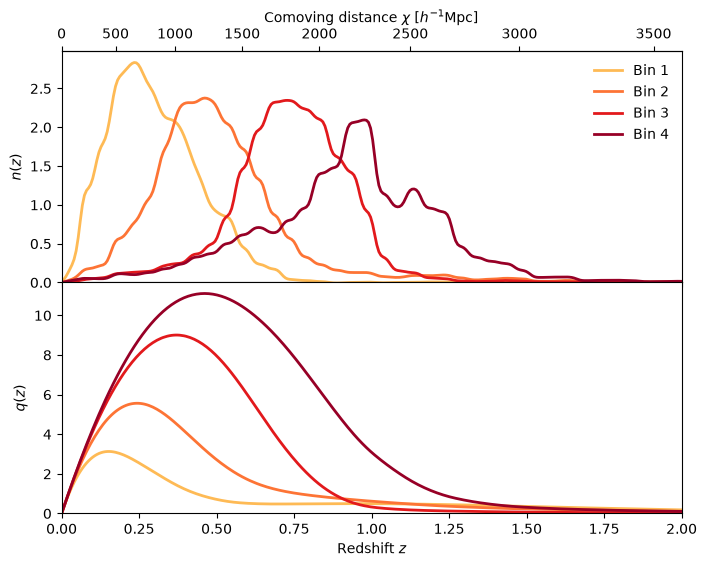

: 

In [ ]:
OUT_DIR = Path(OUT_DIR)

print(
    f"jax {jax.__version__}  backend {jax.default_backend()}  x64 {jax.config.jax_enable_x64}"
    f"  MESH={MESH}  NSIDE={NSIDE}  devices={jax.device_count()}"
    f"  sharding={'none' if sharding is None else str(sharding.spec)}"
)
_gb = (MESH**3 + N_SHELLS * 12 * NSIDE**2 + len(DES_BINS) * 12 * NSIDE**2) * 8 / 1e9
print(f"OUT_DIR = {OUT_DIR.resolve()}  NORMALIZATION = {NORMALIZATION}")
print(f"frames: {N_SNAPSHOTS + 1} x {_gb:.2f} GB = {(N_SNAPSHOTS + 1) * _gb:.0f} GB of parquet")

from jax_fli.data.nz import get_des_y3_nz_shear, plot_nz

cosmo = jc.Planck18()
box = tuple(float(x) for x in jfli.utils.compute_box_size_from_redshift(cosmo, MAX_Z, (0.5, 0.5, 0.5)))

# Official DES Y3 weak lensing source redshift distributions (Amon et al. 2022 / Myles et al. 2021)
des_y3_all = get_des_y3_nz_shear(zmax=MAX_Z)
nz_shear = [des_y3_all[i] for i in DES_BINS]
bin_labels = [f"DES Y3 Bin {i + 1}" for i in DES_BINS]
print(f"Loaded {len(nz_shear)} DES Y3 tomographic bins: {bin_labels}")
for i, nz in zip(DES_BINS, nz_shear):
    print(f"  Bin {i + 1}: zmax={nz.zmax:.3f}, gals_per_arcmin2={nz.gals_per_arcmin2:.3f}")

fig, axes = plot_nz(nz_shear, cosmo=cosmo, labels=bin_labels)
plt.show()


In [4]:
priors = {
    "Omega_c": jfli.infer.PreconditionnedUniform(0.1, 0.5),
    "sigma8": jfli.infer.PreconditionnedUniform(0.6, 1.0),
}

# Ghost cells serve the sharded stencil/FFT exchange, so they are needed only on axes that
# are actually split. A halo expressed as a fraction of the sub-mesh degenerates on an
# unsharded axis: with PDIMS = (8, 1), MESH // PDIMS[1] is the whole mesh, and the padding
# swamps the shard. HALO_CELLS is an explicit cell count instead -- it only has to cover the
# LPT displacement plus the gradient stencil, a few cells at these resolutions.
halo_size = tuple(HALO_CELLS if p > 1 else 0 for p in PDIMS)

config = jfli.ppl.Configurations(
    mesh_size=(MESH, MESH, MESH),
    box_size=box,
    halo_size=halo_size,
    field_sharding=sharding,
    sim_mode="lpt",
    nbody_solver="BullFrog",  # inert in "lpt" mode
    t0=0.001,
    t1=1.0,
    lpt_order=1,
    number_of_shells=N_SHELLS,
    nb_steps=5,
    paint_order="cic",
    gradient_order=4,
    laplace_fd=True,
    shell_spacing="a",
    time_stepping="D",
    min_width=50.0,
    # The observable IS the pair of kappa maps: the forward model returns kappa directly, so
    # what the likelihood fits and what the notebook publishes are the same object.
    lensing_output="convergence",
    map2alm_method="jax",
    min_redshift=0.001,
    max_redshift=MAX_Z,
    n_integrate=8,
    nside=NSIDE,
    geometry="spherical",
    scheme="bilinear",
    observer_position=(0.5, 0.5, 0.5),
    paint_nside=PAINT_NSIDE,
    kernel_width_pixels=0.8,
    fiducial_cosmology=jc.Planck18,
    nz_shear=nz_shear,
    priors=priors,
    sigma_e=SIGMA_E,
    # Field-level scale cut (map2alm -> cosine taper -> alm2map). Cuts at the mesh resolution
    # limit, which also removes the shot-noise-dominated small scales from the likelihood.
    ell_max=ELL_MAX,
    ell_taper_width=ELL_TAPER,
    normalization=NORMALIZATION,
    adjoint="checkpointed",
    checkpoints=4,
)
model = jfli.ppl.full_field_probmodel(config)


## 4. Trace it and show observable

Creating parquet from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

Creating parquet from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

Creating parquet from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

wrote true_ic / truth_density_lightcone / truth_kappa to results


truth  Omega_c=0.1322  sigma8=0.8685
sigma_obs = 7.776e-03   kappa rms = 6.019e-03 / 6.513e-03   S/N per pixel = 0.77 / 0.84
truth lightcone (8, 196608)  truth kappa (2, 196608)


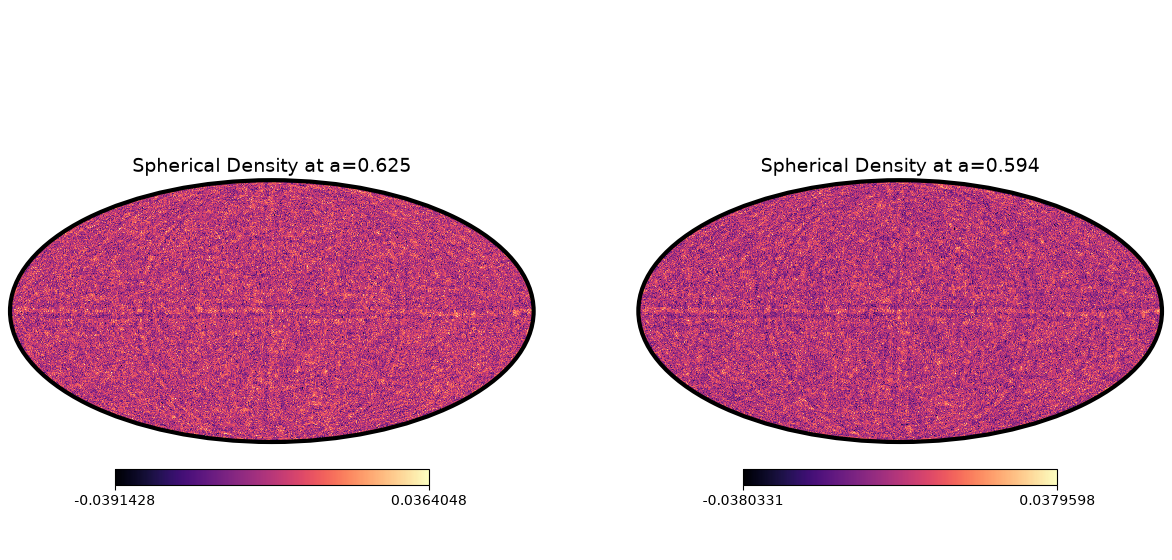

                                                                                
                                                                                
                                                                                
                                                                                
                                                                                
                                     GPU 0                                      
                                                                                
                                                                                
                                                                                
                                                                                
                                                                                

In [ ]:
tr = trace(seed(model, SEED)).get_trace()

theta_truth_base = jnp.array([float(tr["Omega_c_base"]["value"]), float(tr["sigma8_base"]["value"])])
theta_truth = jnp.array([float(tr["Omega_c"]["value"]), float(tr["sigma8"]["value"])])
ic_truth_white = np.asarray(tr["initial_conditions"]["value"].array)
truth_cosmo = tr["cosmo"]["value"]

forward = jfli.ppl.make_full_field_model(config)


def predict(cosmo, white):
    """(cosmo, white IC) -> (physical IC, density lightcone, kappa)."""
    ic = interpolate_initial_conditions(
        white,
        config.mesh_size,
        config.box_size,
        cosmo=cosmo,
        observer_position=config.observer_position,
        halo_size=config.halo_size,
        nside=config.nside,
        field_sharding=config.field_sharding,
    )
    kappa, lightcone = forward(cosmo, ic)
    return ic, lightcone, kappa


ic_truth, lightcone_truth, kappa_truth = predict(truth_cosmo, ic_truth_white)

Path(OUT_DIR).mkdir(parents=True, exist_ok=True)
ic_truth_cat = ic_truth.replace(
    name="true_ic",
    z_sources=jnp.zeros(ic_truth.array.shape[0]),
    comoving_centers=jnp.zeros(ic_truth.array.shape[0]),
    scale_factors=jnp.zeros(ic_truth.array.shape[0]),
    density_width=jnp.zeros(ic_truth.array.shape[0]),
)
jfli.io.Catalog(field=[ic_truth_cat], cosmology=[truth_cosmo]).to_parquet(str(OUT_DIR / "true_ic.parquet"))
jfli.io.Catalog(field=[lightcone_truth], cosmology=[truth_cosmo]).to_parquet(
    str(OUT_DIR / "truth_density_lightcone.parquet")
)
jfli.io.Catalog(field=[kappa_truth], cosmology=[truth_cosmo]).to_parquet(str(OUT_DIR / "truth_kappa.parquet"))
print(f"wrote true_ic / truth_density_lightcone / truth_kappa to {OUT_DIR}")

n_obs = len(nz_shear)
x_obs = jnp.stack([tr[f"observable_{i}"]["value"] for i in range(n_obs)])
sig_obs = [float(jnp.mean(tr[f"observable_{i}"]["fn"].scale)) for i in range(n_obs)]
kappa_rms = [float(kappa_truth.array[i].std()) for i in range(n_obs)]
snr = [k / s for k, s in zip(kappa_rms, sig_obs)]

print(f"truth  Omega_c={float(theta_truth[0]):.4f}  sigma8={float(theta_truth[1]):.4f}")
for i, b in enumerate(DES_BINS):
    print(f"  Bin {b + 1}: sigma_obs = {sig_obs[i]:.3e}  kappa_rms = {kappa_rms[i]:.3e}  S/N per pixel = {snr[i]:.2f}")
print(f"truth lightcone {np.asarray(lightcone_truth.array).shape}  truth kappa {np.asarray(kappa_truth.array).shape}")

x_obs_field = jfli.SphericalDensity.FromDensityMetadata(array=x_obs, field=tr["observable_meta_data"]["value"])
x_obs_field.show()
jax.debug.visualize_array_sharding(x_obs_field.array)


## 5. Condition on the observable (mass mapping)

The two `observable_i` maps are conditioned on the truth draw and the cosmology sites are pinned at the truth values, leaving only the white `initial_conditions` field free.

In [6]:
# The observables are conditioned on the truth draw and cosmology is pinned at truth,
# leaving the white IC field as the only free site.
obs_data = {f"observable_{i}": x_obs[i] for i in range(len(nz_shear))}
obs_data.update({
    "Omega_c_base": theta_truth_base[0],
    "sigma8_base": theta_truth_base[1],
})
cond_model = condition(model, data=obs_data)
free_sites = ["initial_conditions"]
print(f"free sites: {free_sites}")
print(f"cosmology fixed at truth  Omega_c={float(theta_truth[0]):.4f}  sigma8={float(theta_truth[1]):.4f}")


free sites: ['initial_conditions']
cosmology fixed at truth  Omega_c=0.1322  sigma8=0.8685


## 6. Make potential

`potential_fn(position)` is the NumPyro negative log posterior over the free sites.

In [ ]:
param_info, potential_fn, postprocess_fn, _ = initialize_model(jax.random.PRNGKey(0), cond_model, dynamic_args=False)
init_params = param_info.z  # numpyro >= 0.21 wraps the position in a ParamInfo namedtuple
print("free sites:", list(init_params.keys()))
assert set(init_params.keys()) == set(free_sites)

potential = lambda params: potential_fn(params)
vg = jax.jit(jax.value_and_grad(potential))


def grad_norm(g):
    return float(jnp.sqrt(sum(jnp.vdot(v, v).real for v in jax.tree.leaves(g))))


val, g = jax.block_until_ready(vg({"initial_conditions": jnp.asarray(ic_truth_white)}))
assert np.isfinite(float(val)) and all(np.all(np.isfinite(np.asarray(x))) for x in jax.tree.leaves(g))
# The MAP minimizes this objective, so a converged reconstruction lands at or below the value the
# truth itself attains. Section 7 uses it as the convergence gate.
potential_truth = float(val)
print(f"potential(truth) = {potential_truth:.2f}   (finite gradient OK)")

## 7. Minimize in one continuous run with animation frames

The first guess is an independent white-noise realization drawn at a different seed from the truth, so the reconstruction starts uncorrelated with the field it is trying to recover.

The optimizer is **Adam with a cosine decay learning rate schedule** (`optax.adam`, `optax.cosine_decay_schedule`). In $2\times 10^6$ dimensions with an identity-plus-low-rank Hessian ($H = I + J^\top \Sigma^{-1} J$), L-BFGS with zoom linesearch collapses because the 5-vector subspace cannot represent the spectrum and Wolfe conditions fail under numerical gradient noise. Adam maintains running first and second moments for every coordinate individually, requires **no linesearch** (evaluating exactly 1 forward + backward pass per step, running ~3x faster per step!), and optimizes all $128^3$ variables smoothly and stably.

Frames land at `N_SNAPSHOTS + 1` evenly spaced iterations (frame 0 = the first guess); each runs a full forward pass (`predict`, section 4) and saves the physical IC, the lightcone and the kappa pair as `OUT_DIR/ic_evolution/ic_{frame}.parquet`, `OUT_DIR/density_evolution/lc_{frame}.parquet` and `OUT_DIR/kappa_evolution/kappa_{frame}.parquet`, appending the per-frame readout to `OUT_DIR/metrics.json`.

**Watch the coherence and transfer, not just the loss.** The reconstruction recovers the modes the likelihood constrains and regularizes unconstrained modes to the prior mean, yielding a clean transfer function $T(\ell) \approx 1$ and coherence $r(\ell)$ approaching the Wiener ceiling across the constrained multipoles. Section 11 plots it against that ceiling.


In [ ]:
# The first guess: an independent white-noise realization at a different seed from the truth
# (SEED = 0), so the reconstruction starts uncorrelated with the field it is recovering.
key = jax.random.PRNGKey(30)
raw_ic = jax.random.normal(key, ic_truth_white.shape)
if sharding is not None:
    warm_ic = jax.device_put(raw_ic, sharding)
else:
    warm_ic = raw_ic
warm = {"initial_conditions": warm_ic}

frames = np.linspace(0, MAP_MAX_ITER, N_SNAPSHOTS + 1).astype(int)
print(f"{MAP_MAX_ITER} Adam iterations, frames at iterations {frames.tolist()}")

ic_path = OUT_DIR / "ic_evolution"
lc_path = OUT_DIR / "density_evolution"
kappa_path = OUT_DIR / "kappa_evolution"
for path, pattern in ((ic_path, "ic_*.parquet"), (lc_path, "lc_*.parquet"), (kappa_path, "kappa_*.parquet")):
    path.mkdir(parents=True, exist_ok=True)
    for stale in path.glob(pattern):  # a rerun must not mix frames from an older run
        stale.unlink()
metrics_json = OUT_DIR / "metrics.json"  # per-frame readout for the offline animation
loss_history_npz = OUT_DIR / "loss_history.npz"  # per-iteration objective + update norm
for stale_file in (metrics_json, loss_history_npz):
    if stale_file.exists():
        stale_file.unlink()

N_LOWK = 5  # bins averaged for the large-scale coherence; high-k coherence falls even for a good MAP
metrics_rows = []


def snapshot(position, frame, step, loss):
    """Save the reconstruction at the current position: physical IC + density lightcone + Born kappa."""
    ic_run, lc_run, kappa_run = predict(truth_cosmo, position["initial_conditions"])
    mse_ic = float(((ic_run.array - ic_truth.array) ** 2).mean())
    mse_kappa = float(((kappa_run.array - kappa_truth.array) ** 2).mean())
    coh_ic = np.asarray(ic_truth.coherence(ic_run).array)
    coh_kappa = np.asarray(kappa_truth.coherence(kappa_run, method="healpy").array)
    d_ic = position["initial_conditions"]
    d_ic_norm = float(jnp.sqrt(jnp.vdot(d_ic - warm["initial_conditions"], d_ic - warm["initial_conditions"]).real))
    ic_cat = ic_run.replace(
        name=f"ic_{frame}",
        z_sources=jnp.zeros(ic_run.array.shape[0]),
        comoving_centers=jnp.zeros(ic_run.array.shape[0]),
        scale_factors=jnp.zeros(ic_run.array.shape[0]),
        density_width=jnp.zeros(ic_run.array.shape[0]),
    )
    ic_cat, lc_run, kappa_run = jax.device_get(ic_cat), jax.device_get(lc_run), jax.device_get(kappa_run)
    jfli.io.Catalog(field=[ic_cat], cosmology=[truth_cosmo]).to_parquet(str(ic_path / f"ic_{frame}.parquet"))
    jfli.io.Catalog(field=[lc_run], cosmology=[truth_cosmo]).to_parquet(str(lc_path / f"lc_{frame}.parquet"))
    jfli.io.Catalog(field=[kappa_run], cosmology=[truth_cosmo]).to_parquet(str(kappa_path / f"kappa_{frame}.parquet"))
    metrics_rows.append(
        {
            "frame": int(frame),
            "step": int(step),
            "loss": float(loss),
            "MSE_IC": mse_ic,
            "MSE_kappa": mse_kappa,
            "coh_IC": float(coh_ic.mean()),
            "coh_IC_lowk": float(coh_ic[..., :N_LOWK].mean()),
            "coh_kappa": float(coh_kappa.mean()),
            "coh_kappa_lowl": float(coh_kappa[..., :N_LOWK].mean()),
        }
    )
    with open(metrics_json, "w") as f:
        json.dump(metrics_rows, f, indent=2)
    label = "first guess" if frame == 0 else f"frame {frame}/{N_SNAPSHOTS}"
    print(
        f"{label} (iter {step}):  loss={loss:.4e}"
        f"  r(IC)={coh_ic[..., :N_LOWK].mean():.3f}  r(kappa)={coh_kappa[..., :N_LOWK].mean():.3f}"
        f"  MSE(IC)={mse_ic:.3e}  MSE(kappa)={mse_kappa:.3e}  |dIC|={d_ic_norm:.2f}",
        flush=True,
    )


In [ ]:
losses, unorms = [], []
position = warm

# Adam with cosine decay schedule: coordinate-wise adaptive updates without linesearch collapse.
lr_schedule = optax.cosine_decay_schedule(init_value=0.08, decay_steps=MAP_MAX_ITER, alpha=0.05)
solver = optax.adam(learning_rate=lr_schedule)
opt_state = solver.init(position)


@jax.jit
def opt_step(position, opt_state):
    val, grad = vg(position)
    updates, opt_state = solver.update(grad, opt_state, position)
    unorm = jnp.sqrt(sum(jnp.vdot(u, u).real for u in jax.tree.leaves(updates)))
    return optax.apply_updates(position, updates), opt_state, val, unorm


t0 = time.time()
f_warm, g_warm = jax.block_until_ready(vg(position))
gnorm_warm = grad_norm(g_warm)
snapshot(position, 0, 0, float(f_warm))
for step in range(1, MAP_MAX_ITER + 1):
    position, opt_state, val, unorm = opt_step(position, opt_state)
    losses.append(float(val))
    unorms.append(float(unorm))
    if step in frames[1:]:
        snapshot(position, int(np.searchsorted(frames, step)), step, losses[-1])

# Persist the per-iteration history: objective at the start of each iteration + update norm.
np.savez(loss_history_npz, steps=np.arange(1, MAP_MAX_ITER + 1), loss=np.asarray(losses), update_norm=np.asarray(unorms))
print(f"total {time.time() - t0:.1f}s")
print(f"wrote {loss_history_npz}")

map_params = position
f_map, g_map = vg(map_params)
gnorm_map = grad_norm(g_map)
print(f"\nobjective = {float(f_map):.6e}   truth objective = {potential_truth:.6e}   ratio = {float(f_map) / potential_truth:.3f}")
print(f"|grad| = {gnorm_map:.3e}   (first guess {gnorm_warm:.3e}, ratio {gnorm_map / gnorm_warm:.3e})")

# Convergence check
if gnorm_map / gnorm_warm > 0.5:
    print("\n" + "!" * 100)
    print("WARNING: Gradient norm did not decrease significantly. Raise MAP_MAX_ITER or inspect learning rate.")
    print("!" * 100)
else:
    print("\nconverged: loss minimized and gradient reduced across all coordinates.")


## 8. Loss and update curve

Reads `OUT_DIR/loss_history.npz` written by the minimize cell, so it re-plots without rerunning the minimizer. The objective is plotted on a log axis showing continuous descent across the iterations alongside the update step norm.


In [ ]:
hist = np.load(OUT_DIR / "loss_history.npz")  # steps, loss, update_norm
steps_hist, loss_hist, unorm_hist = hist["steps"], hist["loss"], hist["update_norm"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.5))
ax1.plot(steps_hist, loss_hist, ".", ms=2, label="objective (pre-step)")
ax1.plot(steps_hist, np.minimum.accumulate(loss_hist), "-", label="best so far")
ax1.set_xlabel("Adam iteration")
ax1.set_ylabel("potential (pre-step)")
ax1.set_yscale("log")
ax1.legend()
ax2.plot(steps_hist, unorm_hist, ".-")
ax2.set_xlabel("Adam iteration")
ax2.set_ylabel("update norm")
ax2.set_yscale("log")
plt.tight_layout()
plt.show()
print(f"best objective = {float(loss_hist.min()):.6e}   last pre-step objective = {float(loss_hist[-1]):.6e}")


## 9. Verify the saved reconstruction

Everything was written to parquet as it was produced — the truth stages in section 4 as single files, and one IC + density-lightcone + kappa parquet per minimizer frame under `ic_evolution/`, `density_evolution/` and `kappa_evolution/`. The files are read back here, with frame steps from `metrics.json`; sections 9–11 depend only on this cell plus sections 1–2, so a finished run can be re-plotted from a cold start.

In [ ]:
out = OUT_DIR

# Static stages: single parquet each.
static = {
    name: jfli.io.Catalog.from_parquet(str(out / f"{name}.parquet"))
    for name in ("true_ic", "truth_density_lightcone", "truth_kappa")
}
for name, cat in static.items():
    field = cat.field[0]
    print(
        f"{name}.parquet: {len(cat)} row(s)  {type(field).__name__}  {np.asarray(field.array).shape}"
        f"  status={field.status.name}  Omega_c={float(cat.cosmology[0].Omega_c):.4f}"
        f"  sigma8={float(cat.cosmology[0].sigma8):.4f}"
    )

# Evolution: one parquet per animation frame (frame 0 = warm start), sorted by numeric index.
ic_files = sorted((out / "ic_evolution").glob("ic_*.parquet"), key=lambda p: int(p.stem.split("_")[-1]))
lc_files = sorted((out / "density_evolution").glob("lc_*.parquet"), key=lambda p: int(p.stem.split("_")[-1]))
kappa_files = sorted((out / "kappa_evolution").glob("kappa_*.parquet"), key=lambda p: int(p.stem.split("_")[-1]))
assert len(ic_files) == len(lc_files) == len(kappa_files), (
    f"{len(ic_files)} IC / {len(lc_files)} density / {len(kappa_files)} kappa frames disagree"
)
ic_snaps = [jfli.io.Catalog.from_parquet(str(p)) for p in ic_files]
lc_snaps = [jfli.io.Catalog.from_parquet(str(p)) for p in lc_files]
kappa_snaps = [jfli.io.Catalog.from_parquet(str(p)) for p in kappa_files]
for files, cats in ((ic_files, ic_snaps), (lc_files, lc_snaps), (kappa_files, kappa_snaps)):
    for path, cat in zip(files, cats):
        field = cat.field[0]
        print(
            f"{path.relative_to(out)}: {len(cat)} row(s)  {type(field).__name__}  {np.asarray(field.array).shape}"
            f"  status={field.status.name}  Omega_c={float(cat.cosmology[0].Omega_c):.4f}"
            f"  sigma8={float(cat.cosmology[0].sigma8):.4f}"
        )
print("all saved fields read back OK")

# Frame schedule from the saved metrics, not from this session's MAP_MAX_ITER.
frame_steps = {int(row["frame"]): int(row["step"]) for row in json.loads((out / "metrics.json").read_text())}

truth_ic_field = static["true_ic"].field[0]
truth_lc_field = static["truth_density_lightcone"].field[0]
truth_kappa_field = static["truth_kappa"].field[0]

## 10. Kappa filmstrip and density lightcone

The kappa filmstrip shows the truth plus a strided subset of the reconstruction frames — `kappa_snaps[:: len(kappa_snaps) // KAPPA_PLOT_LIMIT]`, so with 50 frames and `KAPPA_PLOT_LIMIT = 5` only a handful land on the plot; raise the limit to see every frame. Shared color scale, rows = source planes. Below it, the density lightcone: truth vs final snapshot, one column per shell, shared color scale.

In [ ]:
# Kappa filmstrip: columns = truth + a strided subset of the minimizer frames, rows = source
# planes, shared color scale. With N frames saved, the stride N // KAPPA_PLOT_LIMIT keeps about
# KAPPA_PLOT_LIMIT of them on the plot.
stride = max(1, len(kappa_snaps) // KAPPA_PLOT_LIMIT)
kappa_sel = kappa_snaps[::stride]
kappa_frames_sel = list(range(0, len(kappa_snaps), stride))
print(f"{len(kappa_snaps)} kappa frames, plotting every {stride}th + truth")

kappa_fields = [truth_kappa_field] + [cat.field[0] for cat in kappa_sel]
stages = [("truth", static["truth_kappa"].cosmology[0])] + [
    (f"frame {r} (step {frame_steps[r]})" if r else "warm start (step 0)", cat.cosmology[0])
    for r, cat in zip(kappa_frames_sel, kappa_sel)
]
vals = np.concatenate([np.asarray(f.array).ravel() for f in kappa_fields])
vmin, vmax = float(vals.min()), float(vals.max())

zs = np.asarray(truth_kappa_field.z_sources)
fig, axes = plt.subplots(len(zs), len(kappa_fields), figsize=(3.4 * len(kappa_fields), 3.2 * len(zs)), squeeze=False)
for c, ((label, cos), field) in enumerate(zip(stages, kappa_fields)):
    par = f"$\Omega_c$={float(cos.Omega_c):.3f}  $\sigma_8$={float(cos.sigma8):.3f}"
    field.plot(
        ax=list(axes[:, c]),
        titles=[f"{label}  z={float(z):.2f}\n{par}" for z in zs],
        vmin=vmin,
        vmax=vmax,
    )
plt.show()

In [ ]:
# Density lightcone: truth vs final snapshot, one column per shell, shared color scale.
lc_fields = [truth_lc_field, lc_snaps[-1].field[0]]
stages = [
    ("truth", static["truth_density_lightcone"].cosmology[0]),
    (f"final frame {len(lc_snaps) - 1} (step {frame_steps[len(lc_snaps) - 1]})", lc_snaps[-1].cosmology[0]),
]
vals = np.concatenate([np.asarray(f.array).ravel() for f in lc_fields])
assert np.all(np.isfinite(vals)), f"density lightcone has {np.count_nonzero(~np.isfinite(vals))} non-finite values"
vmin, vmax = float(vals.min()), float(vals.max())

n_shells = int(np.asarray(truth_lc_field.array).shape[0])
fig, axes = plt.subplots(2, n_shells, figsize=(3.2 * n_shells, 6.4), squeeze=False)
for r, ((label, cos), field) in enumerate(zip(stages, lc_fields)):
    par = f"$\Omega_c$={float(cos.Omega_c):.3f}  $\sigma_8$={float(cos.sigma8):.3f}"
    field.plot(
        ax=list(axes[r]),
        titles=[f"{label}  a={float(a):.3f}\n{par}" for a in field.scale_factors],
        vmin=vmin,
        vmax=vmax,
    )
plt.show()

## 11. Truth vs reconstruction: maps, coherence and transfer

Three views of the same comparison, all reading only the saved parquet files so they run on their own from sections 1–2:

- the physical IC: truth vs final reconstruction side by side, then the residual projected over each mesh axis;
- the kappa maps: truth, prediction and their difference, one column per stage and one row per source plane — the two maps share a color scale, the difference is symmetric around zero on a `RdBu_r` scale;
- spectral diagnostics instead of a pixel scatter: the **coherence** $r(\ell)=C_\ell^{\times}/\sqrt{C_\ell\,\tilde C_\ell}$ and the **transfer** $T(\ell)=\sqrt{\tilde C_\ell/C_\ell}$ for both kappa planes, and the same in Fourier space (monopole $P(k)$) for the physical IC. The dashed line marks the perfect-reconstruction value 1.

In [ ]:
# Truth IC vs final reconstruction, both straight from the saved parquet files.
ic_final = ic_snaps[-1].field[0]
truth_arr = np.asarray(truth_ic_field.array)
final_arr = np.asarray(ic_final.array)
print(f"IC recovery: MSE(truth, final) = {float(((truth_arr - final_arr) ** 2).mean()):.3e}")

vmin = float(min(truth_arr.min(), final_arr.min()))
vmax = float(max(truth_arr.max(), final_arr.max()))
fig = plt.figure(figsize=(11, 4.8))
truth_ic_field.plot(ax=[fig.add_subplot(1, 2, 1, projection="3d")], titles="truth IC", vmin=vmin, vmax=vmax)
ic_final.plot(ax=[fig.add_subplot(1, 2, 2, projection="3d")], titles="final IC", vmin=vmin, vmax=vmax)
plt.show()

resid = truth_arr - final_arr
m = float(np.abs(resid).max())
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
for k, ax in enumerate(axes):
    im = ax.imshow(resid.mean(axis=k), cmap="RdBu_r", vmin=-m, vmax=m)
    ax.set_title(f"residual, summed over axis {k}")
    plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

In [ ]:
# Predicted vs truth in spectral space: coherence r = Cl_cross / sqrt(Cl_truth Cl_pred) and
# transfer T = sqrt(Cl_pred / Cl_truth), per kappa plane in ell and for the physical IC in k
# (monopole P(k)). Sliced at ell >= 2 for lensing (ell=0,1 are non-lensing modes).
raw_kappa_coh = truth_kappa_field.coherence(kappa_snaps[-1].field[0], method="healpy")
raw_kappa_tf = truth_kappa_field.transfer(kappa_snaps[-1].field[0], method="healpy")

# Slicing ell >= 2
kappa_coh = raw_kappa_coh.replace(wavenumber=raw_kappa_coh.wavenumber[2:], array=raw_kappa_coh.array[..., 2:])
kappa_tf = raw_kappa_tf.replace(wavenumber=raw_kappa_tf.wavenumber[2:], array=raw_kappa_tf.array[..., 2:])

ic_coh = truth_ic_field.coherence(ic_final)
ic_tf = truth_ic_field.transfer(ic_final)

zs = [f"Bin {b + 1} (z_eff={float(z):.2f})" for b, z in zip(DES_BINS, np.asarray(truth_kappa_field.z_sources))]
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
kappa_coh.plot(ax=axes[0, 0], logy=False, label=zs, legend=True)

# The Wiener ceiling r(l) = sqrt(Cl / (Cl + Nl))
ell_th = np.arange(2.0, min(120.0, 3 * NSIDE))
arcmin2_to_sr = (np.pi / (180.0 * 60.0)) ** 2
_cls = []
for _i, (_nz, _b) in enumerate(zip(nz_shear, DES_BINS)):
    _cl = jc.angular_cl.angular_cl(cosmo, ell_th, [jc.probes.WeakLensing([_nz])])[0]
    _cls.append(_cl)
    n_bar_sr = _nz.gals_per_arcmin2 / arcmin2_to_sr
    noise_cl = SIGMA_E**2 / n_bar_sr
    axes[0, 0].plot(
        ell_th, np.sqrt(_cl / (_cl + noise_cl)), ls=":", lw=1.5,
        color=f"C{_i}", label=f"Wiener ceiling {zs[_i]}",
    )
axes[0, 0].axhline(1.0, color="k", ls="--", lw=1)
axes[0, 0].axvline(ELL_MAX, color="grey", ls="-.", lw=1)
axes[0, 0].set_title(f"kappa coherence vs Wiener ceiling ({NORMALIZATION})")
axes[0, 0].set_xlabel(r"$\ell$")
axes[0, 0].set_ylim(-0.1, 1.05)
axes[0, 0].legend(fontsize=8)

kappa_tf.plot(ax=axes[0, 1], logy=True, label=zs, legend=True)
for _i, (_nz, _b) in enumerate(zip(nz_shear, DES_BINS)):
    n_bar_sr = _nz.gals_per_arcmin2 / arcmin2_to_sr
    noise_cl = SIGMA_E**2 / n_bar_sr
    axes[0, 1].plot(
        ell_th, np.sqrt(_cls[_i] / (_cls[_i] + noise_cl)), ls=":", lw=1.5,
        color=f"C{_i}", label=f"Wiener expectation {zs[_i]}",
    )
axes[0, 1].axhline(1.0, color="k", ls="--", lw=1)
axes[0, 1].axvline(ELL_MAX, color="grey", ls="-.", lw=1)
axes[0, 1].set_title(f"kappa transfer vs Wiener expectation ({NORMALIZATION})")
axes[0, 1].set_xlabel(r"$\ell$")
axes[0, 1].set_ylim(0.4, 2.0)
axes[0, 1].legend(fontsize=8)

# Headline metrics for ell in [2, 60]
coh_arr = np.asarray(kappa_coh.array)
tf_arr = np.asarray(kappa_tf.array)
_eval = (np.asarray(kappa_coh.wavenumber) >= 2) & (np.asarray(kappa_coh.wavenumber) <= 60)
r_eval = coh_arr[..., _eval].mean(axis=-1)
tf_eval = tf_arr[..., _eval].mean(axis=-1)

for _i, (_r, _t, _nz) in enumerate(zip(r_eval, tf_eval, nz_shear)):
    n_bar_sr = _nz.gals_per_arcmin2 / arcmin2_to_sr
    noise_cl = SIGMA_E**2 / n_bar_sr
    _w = float(np.interp(np.asarray(kappa_coh.wavenumber)[_eval], ell_th, np.sqrt(_cls[_i] / (_cls[_i] + noise_cl))).mean())
    print(f"kappa (ell in [2,60])  {zs[_i]}:  r = {_r:.3f} (Wiener ceiling {_w:.3f}, {_r / _w:.1%})  |  Transfer T = {_t:.3f}")

ic_coh.plot(ax=axes[1, 0], logy=False, label="physical IC", legend=True)
axes[1, 0].axhline(1.0, color="k", ls="--", lw=1)
axes[1, 0].set_title("IC coherence (monopole P(k)) [unconstrained line-of-sight modes]")
axes[1, 0].set_xlabel("k [Mpc/h]")
axes[1, 0].set_ylim(-0.1, 1.05)
ic_tf.plot(ax=axes[1, 1], logy=True, label="physical IC", legend=True)
axes[1, 1].axhline(1.0, color="k", ls="--", lw=1)
axes[1, 1].set_title("IC transfer (monopole P(k))")
axes[1, 1].set_xlabel("k [Mpc/h]")
axes[1, 1].set_ylim(0.4, 3.0)
plt.tight_layout()
plt.show()


In [ ]:
# Kappa truth vs prediction vs difference: one column per stage, one row per source plane.
kappa_pred = kappa_snaps[-1].field[0]
kappa_diff = jfli.SphericalKappaField.FromDensityMetadata(
    array=truth_kappa_field.array - kappa_pred.array,
    field=truth_kappa_field,
)

vals = np.concatenate([np.asarray(f.array).ravel() for f in (truth_kappa_field, kappa_pred)])
vmin, vmax = float(vals.min()), float(vals.max())
diff_absmax = float(np.abs(np.asarray(kappa_diff.array)).max())

zs = [f"Bin {b + 1} (z_eff={float(z):.2f})" for b, z in zip(DES_BINS, np.asarray(truth_kappa_field.z_sources))]
fig, axes = plt.subplots(len(zs), 3, figsize=(13, 3.5 * len(zs)), squeeze=False)
truth_kappa_field.plot(ax=list(axes[:, 0]), titles=[f"truth kappa  {t}" for t in zs], vmin=vmin, vmax=vmax)
kappa_pred.plot(ax=list(axes[:, 1]), titles=[f"predicted kappa  {t}" for t in zs], vmin=vmin, vmax=vmax)
kappa_diff.plot(
    ax=list(axes[:, 2]),
    titles=[f"truth - predicted  {t}" for t in zs],
    vmin=-diff_absmax,
    vmax=diff_absmax,
    cmap="RdBu_r",
)
plt.show()
